# Spatial Data

This chapter grounds the ideas discussed in the previous two chapters into a practical context. We consider how data structures, and the data models they represent, are implemented in Python. We also cover how to interact with these data structures. This will happen alongside the code used to manipulate the data in a single computational laboratory notebook. This, then, unites the two concepts of open science and geographical thinking. 

Further, we will spend most of the chapter discussing how Python represents data
*once read* from a file or database, rather than focusing on specific *file*
formats used to store data. This is because the libraries we use will read any
format into one of a few canonical data structures that we discuss in Chapter 1.
We take this approach because these data structures are what we interact with
during our data analysis: they are our interface with the data. File formats, while useful, are secondary to this purpose. Indeed, part of the benefit of Python (and other computing languages) is *abstraction*: the complexities, particularities and quirks associated with each file format are removed as Python represents all data in a few standard ways, regardless of provenance. We take full advantage of this feature here. 

We divide the chapter in two main parts. The first part looks at each of the
three main data structures reviewed in Chapter 1 (*Geographic Thinking*):
geographic tables, surfaces and spatial graphs. Second, we explore combinations
of different data structures that depart from the traditional data
model/structure matchings discussed in Chapter 2. We cover how one data in one
structure can be effectively transferred to another, but also we discuss why that might (or might not) be a good idea in some cases. A final note before we delve into the content of this book is in order: this is not a comprehensive account of *everything* that is possible with each of the data structures we present. Rather, you can think of it as a preview that we will build on throughout the book to showcase much of what is possible with Python.

In [1]:
import pyproj
import pandas
import osmnx
import geopandas
import rioxarray
import xarray
import datashader
import contextily as cx
from shapely import geometry
import matplotlib.pyplot as plt

/Users/Adnan/miniconda3/envs/sds/lib/python3.9/site-packages/pyproj/__init__.py:95: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


**Check your current working directory:**

In [29]:
import os

# Get the current working directory
current_directory = os.getcwd()

# Print the current working directory
print("Current working directory:", current_directory)

Current working directory: /Users/Adnan/Siddique/Work-Related/Teaching/ITU/Spatial Data Science/Spring 2025/code-sds-sp2025/Notebooks


## Fundamentals of geographic data structures (Part II)

### Surfaces

Surfaces are used to record data from a field data model. In theory, a field is
a continuous surface and thus has an infinite number of locations at which it
could be measured. In reality, however, fields are measured at a finite sample
of locations that, to provide a sense of continuity and better conform with the
field model, are uniformly structured across space. Surfaces thus are
represented as grids where each cell contains a sample. A grid can also be
thought of as a table with rows and columns but, as we discussed in the previous
chapter, both of them are directly tied to a geographic location. This is in sharp contrast with geographic tables, where geography is confined to a single column.

To explore how Python represents surfaces, we will use an extract for the Brazilian city of Sao Paulo of a [global population dataset](../data/ghsl/build_ghsl_extract). This dataset records population counts in cells of the same dimensions uniformly covering the surface of the Earth. Our extract is available as a GeoTIF file, a variation of the TIF image format that includes geographic information. We can use the `open_rasterio()` method from the `rioxarray` package to read in the GeoTIF:

In [30]:
pop = rioxarray.open_rasterio("../Course-Datasets/ghsl_sao_paulo.tif")

This reads the data into a `DataArray` object:

In [31]:
type(pop)

xarray.core.dataarray.DataArray

`xarray` is a package to work with multi-dimensional labeled arrays. Let's
unpack this: we can use arrays of not only two dimensions as in a table with
rows and columns, but also with an arbitrary number of them; each of these dimensions is "tracked" by an index that makes it easy and efficient to manipulate. In `xarray`, these indices are called coordinates, and they can be retrieved from our `DataArray` through the `coords` attribute:

In [32]:
pop.coords

Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 4kB -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06
  * y            (y) float64 3kB -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
    spatial_ref  int64 8B 0

Interestingly, our surface has *three* dimensions: `x`, `y`, and `band`. The former two track the latitude and longitude that each cell in our population grid covers. The third one has a single value (1) and, in this context, it is not very useful. But it is easy to imagine contexts where a third dimension would be useful. For example, an optical color image may have three bands: red, blue, and green. More powerful sensors may pick up additional bands, such as near infrared (NIR) or even radio bands. Or, a surface measured over time, like the geocubes that we discussed in Chapter 2, will have bands for each point in time at which the field is measured. A geographic surface will thus have two dimensions recording the location of cells (`x` and `y`), and at least one `band` that records other dimensions pertaining to our data.

An `xarray.DataArray` object contains additional information about the values stored under the `attrs` attribute:

In [33]:
pop.attrs

{'AREA_OR_POINT': 'Area',
 '_FillValue': np.float32(-200.0),
 'scale_factor': 1.0,
 'add_offset': 0.0}

In this case, we can see this includes information required to convert pixels in the array into locations on the Earth surface (e.g., `transform`, and `crs`), the spatial resolution (250 meters by 250 meters), and other metadata that allows us to better understand where the data comes from and how it is stored.

Thus, our `DataArray` has three dimensions:

In [34]:
pop.shape

(1, 416, 468)

A common operation will be to reduce this to only the two geographic ones. We can do this with the `sel` operator, which allows us to select data by the value of their coordinates:

In [35]:
pop.sel(band=1)

<xarray.DataArray (y: 416, x: 468)> Size: 779kB
[194688 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 4kB -4.482e+06 -4.482e+06 ... -4.365e+06 -4.365e+06
  * y            (y) float64 3kB -2.822e+06 -2.822e+06 ... -2.926e+06 -2.926e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -200.0
    scale_factor:   1.0
    add_offset:     0.0

The resulting object is thus a two-dimensional array. Similar to geographic tables, we can quickly plot the values in our dataset:

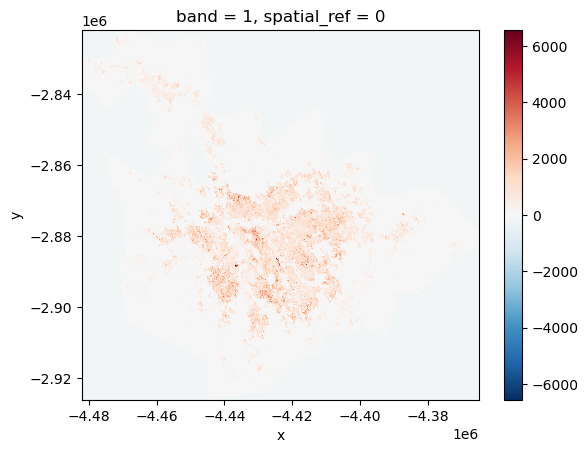

In [36]:
pop.sel(band=1).plot();

This gives us a first overview of the distribution of population in the Sao Paulo region. However, if we inspect the map further, we can see that the map includes negative counts! How could this be? As it turns out, missing data is traditionally stored in surfaces not as a class of its own (e.g., `NaN`) but with an impossible value. If we return to the `attrs` printout above, we can see how the `nodatavals` attribute specifies missing data recorded with -200. With that in mind, we can use the `where()` method to select only values that are *not* -200:

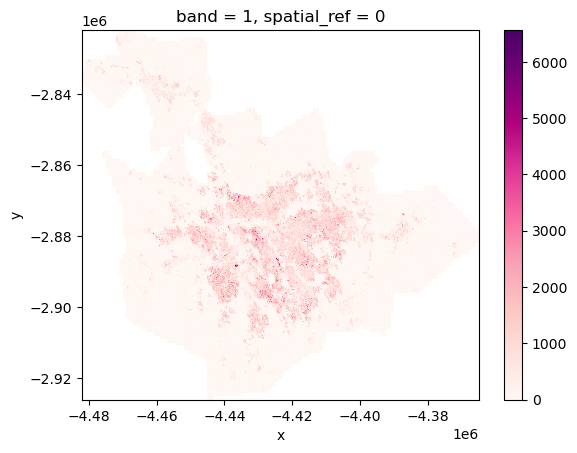

In [37]:
pop.where(pop != -200).sel(band=1).plot(cmap="RdPu");

The colorbar now looks more sensible, and indicates *real* counts, rather than including the missing data placeholder values.

:exclamation: Use the method `.rio.resolution()` to extract the pixel dimensions for this data?

In [ ]:
# your code here

(250.0, -250.0)

:exclamation: Use the method `.rio.crs` to extract the coordinate reference system (CRS) for this data?

In [51]:
crs = pop.rio.crs
crs

CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Mollweide"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

---


### Spatial graphs

Spatial graphs store connections between objects through space. These
connections may derive from geographical topology (e.g., contiguity), distance,
or more sophisticated dimensions such as interaction flows (e.g., commuting,
trade, communication). Compared to geographic tables and surfaces, spatial
graphs are rather different. First, in most cases they do not record
measurements about given phenomena, but instead focus on *connections*, on
storing relationships between objects as they are facilitated (or impeded in
their absence) by space. Second, because of this relational nature, the data are
organized in a more unstructured fashion: while one sample may be connected to
only one other sample, another one can display several links. This is in stark contrast to geographic tables and surfaces, both of which have a clearly defined structure, shape and dimensionality in which data are organized. 

These particularities translate into a different set of Python data structures. Unlike the previous data structures we have seen, there are quite a few data structures to represent spatial graphs, each optimized for different contexts. One such case is the use of spatial connections in statistical methods such as exploratory data analysis or regression. For this, the most common data structure are spatial weights matrices, to which we devote the next chapter. 

In this chapter, we briefly review a different way of representing spatial graphs that is much closer to the mathematical concept of a graph. A graph is composed of *nodes* that are linked together by *edges*. In a spatial network, *nodes* may represent geographical places, and thus have a specific location; likewise, *edges* may represent geographical paths between these places. Networks require both *nodes* and *edges* to analyze their structure. 

For illustration, we will rely on the `osmnx` library, which can query data from OpenStreetMap. For example, we extract the street-based graph of Yoyogi Park, near our earlier data from Tokyo:

In [ ]:
graph = osmnx.graph_from_place("Yoyogi Park, Shibuya, Tokyo, Japan")

In [ ]:
osmnx.save_graphml(graph, "../data/cache/yoyogi_park_graph.graphml")

The code snippet above sends the query to the OpenStreetMap server to fetch the data. Note that the cell above _requires_ internet connectivity to work. If you are working on the book _without_ connectivity, a cached version of the graph is available on the data folder and can be read as:

In [ ]:
graph = osmnx.load_graphml("../data/cache/yoyogi_park_graph.graphml")

Once the data is returned to `osmnx`, it gets processed into the `graph` Python representation:

In [ ]:
type(graph)

networkx.classes.multidigraph.MultiDiGraph

We can have a quick inspection of the structure of the graph with the `plot_graph` method:

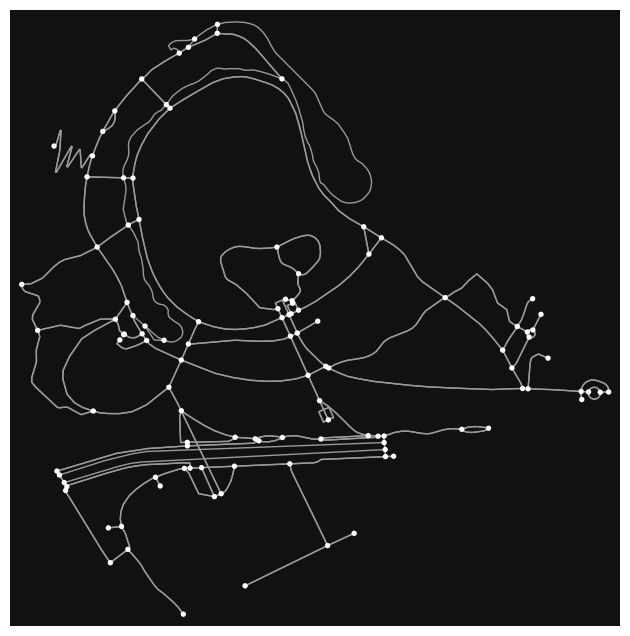

In [ ]:
osmnx.plot_graph(graph);

The resultant `graph` object is actually a `MultiDiGraph` from `networkx`, a graph library written in Python. The graph here is stored as a collection of 106 nodes (street intersections):

In [ ]:
len(graph.nodes)

113

and 287 edges (streets) that connect them:

In [ ]:
len(graph.edges)

305

Each of these elements can be queried to obtain more information such as the location and ID of a node:

In [ ]:
graph.nodes[1520546819]

{'y': 35.6711267, 'x': 139.6925951, 'street_count': 4}

The characteristics of an edge:

In [ ]:
graph.edges[(1520546819, 3010293622, 0)]

{'osmid': 138670840,
 'highway': 'footway',
 'oneway': False,
 'reversed': False,
 'length': 59.113074370021955,
 'geometry': <LINESTRING (139.693 35.671, 139.693 35.671, 139.693 35.671)>}

Or how the different components of the graph relate to each other. For example, what other nodes are directly connected to node `1520546819`?

In [ ]:
list(graph.adj[1520546819].keys())

[3010293622, 5764960322, 1913626649, 1520546959]

Thus, networks are easy to represent in Python, and are one of the three main data structures in geographic data science. 



## Hybrids

We have just seen how geographic tables, surfaces, and networks map onto `GeoDataFrame`, `DataArray` and `Graph` objects in Python, respectively. These represent the conventional pairings that align data models to data structures with Python representations. However, while the conventional pairings are well-used, there are others in active use and many more to yet be developed. Interestingly, many new pairings are driven by new developments in technology, enabling approaches that were not possible in the past or creating situations (e.g., large datasets) that make the conventional approach limiting. Therefore, in this second section of the chapter, we step a bit "out of the box" to explore cases in which it may make sense to represent a dataset with a data structure that might not be the most obvious initial choice. 


### Surfaces as tables

The first case we explore is treating surfaces as (geo-)tables. In this context, we shift from an approach where each dimension has a clear mapping to a spatial or temporal aspect of the dataset, to one where each sample, cell of the surface/cube is represented as a row in a table. This approach runs contrary to the general consensus that fields are best represented as surfaces or rasters because that allows us to index space and time "by default" based on the location of values within the data structure. Shifting to a tabular structure implies either losing that space-time reference, or having to build it manually with auxiliary objects (e.g., a spatial graph). In almost any case, operating on this format is less efficient than it *could* be if we had bespoke algorithms built around surface structures. Finally, from a more conceptual point of view, treating pixels as independent realizations of a process that we *know* is continuous can be computationally inefficient and statistically flawed. 

This perspective, however, also involves important benefits. First, sometimes we *don't* need location for our particular application. Maybe we are interested in calculating overall descriptive statistics; or maybe we need to run an analysis that is entirely atomic in the sense that it operates on each sample in isolation from all the other ones.  Second, by "going tabular" we recast our specialized, spatial data into the most common data structure available, for which a large amount of commodity technology is built. This means many new tools can be used for analysis. So-called "big data" technologies, such as distributed systems, are much more common, robust, and tested for tabular data than for spatial surfaces. *If* we can translate our spatial challenge into a tabular challenge, we can immediately plug in technology that is more optimized and, in some cases, reliable. Further, some analytic toolboxes common in (geographic) data science are entirely built around tabular structures. Machine learning packages such as `scikit-learn`, or some spatial analytics (such as most methods in the Pysal family of packages) are designed around this data structure. Converting our surfaces into tables thus allows us to plug into a much wider suite of (potentially) efficient tools and techniques.

We will see two ways of going from surfaces to tables: one converts every pixel into a table row, and another aggregates pixels into pre-determined polygons.

#### One pixel at a time

Technically, going from surface to table involves traversing from `xarray` to `pandas` objects. This is actually a well established bridge. To illustrate it with an example, let's revisit the population counts in [Sao Paulo](../data/ghsl/build_ghsl_extract) used earlier. We can read the surface into a `DataArray` object with `rioxarray`, a special package designed to work with raster data in `xarray`. We can use its `open_rasterio()` method to read in the data:

In [ ]:
surface = rioxarray.open_rasterio("../Course-Datasets/ghsl_sao_paulo.tif")

Transferring to a table is as simple as calling the `DataArray`'s `to_series()` method:

In [ ]:
t_surf = surface.to_series()

The resulting object is a `pandas.Series` object indexed on each of the dimensions of the original `DataArray`:

In [ ]:
t_surf.head(5)

band  y           x         
1     -2822125.0  -4481875.0   -200.0
                  -4481625.0   -200.0
                  -4481375.0   -200.0
                  -4481125.0   -200.0
                  -4480875.0   -200.0
dtype: float32

:question: What do you see one y-value against so many x-values?

# Your answer here.

At this point, everything we know about `pandas` and tabular data applies! For example, it might be more convenient to express it as a `DataFrame`:

In [ ]:
t_surface = t_surf.reset_index().rename(columns={0: "Value"})
t_surface

:question: How many rows does this dataframe have? Is it related to the raster dimensions?

# Your answer here.

:question: What the the purpose of `.reset_index()`? What if we don't use it?

# Your answer here.

:question: What is the reason for `.rename(columns={0: "Value"})`?

# Your answer here.

With the power of a tabular library, some queries and filter operations become much easier. For example, finding cells with more than 200 people can be done with the usual `query()` method.[^xarray-query]

:exclamation: Use the `.query()` method to filter the rows with more than 200 people.

In [ ]:
# your code here

:exclamation: Use the `.info()` method to get a data summary for the filtered dataframe.

In [41]:
# your code here

:question: Does this dataframe have geometry information with it?

# Your answer here.

***

Note:
- The table we have built has no geometries associated with it, only rows representing pixels. 

It takes a bit more effort, but it is possible to convert it, or a subset of it, into a fully-fledged geographic table, where each pixel includes the grid geometry it represents. 

In [ ]:
def extract_resolution(dataArray_obj):
    """EXTRACT_RESOLUTION pulls up the data resolution of the grid from an xarray.DataFrame object

    - It works if .attrs method is defined for the object.
    - The function returns resolution in (x,y) as a tuple

    A single argument is expected.

    """
    
    data_resolution = ... # your code here.
    return data_resolution


By now, we have solved the problem of extracting the required grid resolution.

In [52]:
def prepare_box_geometry_single_row(row, res_xy):
    """PREPARE_BOX_GEOMETRY_SINGLE_ROW can be used to prepare geometry column, when constructing a 
    geotable from a normal table or data frame. It works for a single row, but can be called subsequently
    using apply() routine to work row-wise for an entire data frame.

    INPUTS:

    - row: this is a single row of a table or data frame
    - resxy: the resolution of the data (can be obtained using extract_resolution() function)

    OUTPUT:
    - a box geometry (polygon)
    
    """
    res_x, res_y = res_xy  # Extract resolution for each dimension
    # XY Coordinates are centered on the pixel
    
    minX = row["x"] - (res_x / 2)
    maxX = ...
    minY = row["y"] + (res_y / 2)
    maxY = ...
    
    poly = geometry.box(
        minX, minY, maxX, maxY
    )  # Build squared polygon
    return poly

Let's check if it is working properly. 

1. we select a row (as example)
2. note down its `x` and `y` figures, i.e. the coordinates
3. call the `prepare_box_geometry_single_row()`
4. check if the resulting geometry is what we would have expected


In [ ]:
geom_row = prepare_box_geometry_single_row(t_surface.iloc[0], ...)
geom_row

:exclamation: Check the validity of the geometry you have just created using the `is_valid` method.

In [ ]:
# your code here

So it seems to work fine! Now we apply this function row-wise, and prepare the necessary geometries!

In [ ]:
geoms = t_surface.apply(prepare_box_geometry_single_row, axis = 1, res_xy = ...)
geoms

**Further work in next week, iA**